In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [12]:
V=[17.3*(10**(-6))/2,16/2*(10**(-6)),14.3*(10**(-6))/2,13.1*(10**(-6))/2,11.4*(10**(-6))/2,10.2*(10**(-6))/2,8.5*(10**(-6))/2,7.4*(10**(-6))/2,5.6*(10**(-6))/2,4.5*(10**(-6))/2,2.8*(10**(-6))/2,1.7*(10**(-6))/2]
V # mjerenja napona

[8.65e-06,
 8e-06,
 7.15e-06,
 6.549999999999999e-06,
 5.7e-06,
 5.0999999999999995e-06,
 4.25e-06,
 3.7e-06,
 2.8e-06,
 2.25e-06,
 1.4e-06,
 8.499999999999999e-07]

In [13]:
I=[3/50,2.8/50,2.5/50,2.3/50,2/50,1.8/50,1.5/50,1.3/50,1/50,0.8/50,0.5/50,0.3/50]
I # mjerenja struje

[0.06,
 0.055999999999999994,
 0.05,
 0.046,
 0.04,
 0.036000000000000004,
 0.03,
 0.026000000000000002,
 0.02,
 0.016,
 0.01,
 0.006]

# $$y=ax+b$$


# $$a = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}$$

# $$b = \frac{\sum x_i^2 \sum y_i - \sum x_i \sum x_iy_i}{n\sum x_i^2 - (\sum x_i)^2}$$

# $$M_a = \sqrt{\frac{1}{n-2} \left[ \frac{n\sum y_i^2  - (\sum y_i)^2}{n \sum x_i^2 - (\sum x_i)^2} -a^2 \right]}$$



# $$M_b = M_a\sqrt{\frac{1}{n}\sum x_i^2}$$


In [27]:
###Suma XiYi
N=len(I)
sxy=0
i=N-1
j=0

while (j<=i):
    sxy=sxy+V[j]*I[j]
    j=j+1
   

#####Suma Xi

sx=0
i=11
j=0
while (j<=i):
    sx=sx+I[j]
    j=j+1
    

######Suma Yi

sy=0
i=11
j=0
while (j<=i):
    sy=sy+V[j]
    j=j+1
   

####Suma Xi^2

sx2=0
i=11
j=0
while (j<=i):
    sx2=sx2+(I[j])**2
    j=j+1
    

#####Suma Yi^2$

sy2=0
i=11
j=0
while (j<=i):
    sy2=sy2+(V[j])**2
    j=j+1
 

##############
a=(N*sxy-sx*sy)/(N*sx2-(sx)**2)
###############
b=(sx2*sy-sx*sxy)/(N*sx2-(sx)**2)
############
Ma=np.sqrt((1/(N-2))*((N*sy2-sy**2)/(N*sx2-sx**2)-a**2))
#################
Mb=Ma*np.sqrt((1/N)*sx2)

print(f'V = ({a:.7f} +- {Ma:.7f}) * I + ({b:.9f} +- {Mb:.9f})')

V = (0.0001429 +- 0.0000002) * I + (-0.000000007 +- 0.000000005)


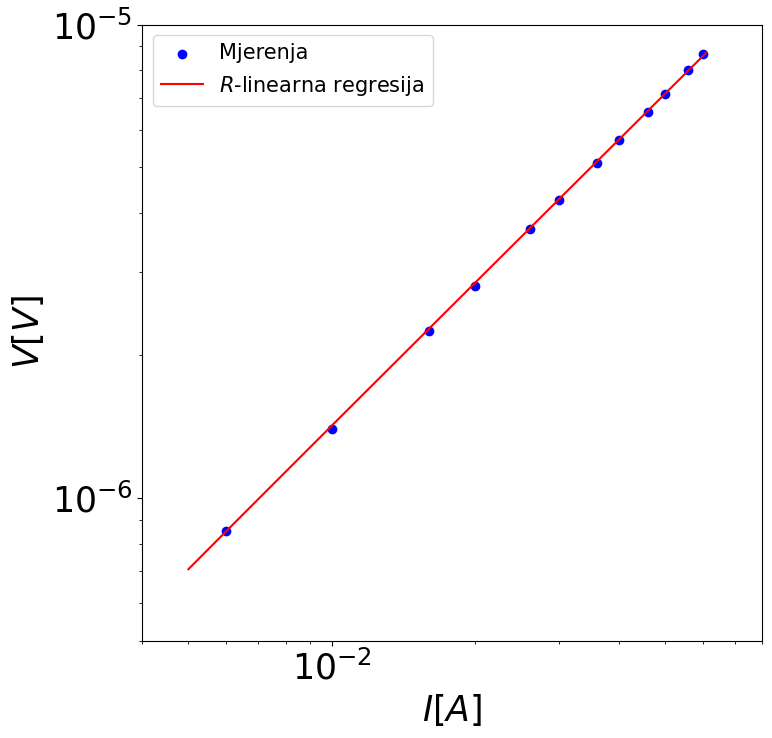

In [30]:
plt.rcParams['figure.figsize'] = [8,8]
fig1=plt.figure(1)
x = np.linspace(0.005, 0.061)
plt.scatter(I, V,color='blue',label=r'Mjerenja')

plt.plot(x,a*x+b,color='red',label='$R $-linearna regresija')

plt.legend(fontsize=15)
plt.xlabel(r'$I [A]$') 
plt.ylabel(r'$V[  V ]$')

plt.rcParams.update({'font.size': 25})
plt.axis([0.004, 0.08, 0.0000005, 0.00001])
plt.yscale('log')
plt.xscale('log')
plt.show()